In [1]:
from bs4 import BeautifulSoup
import requests
import folium
import pandas as pd
import re
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from urllib.parse import urlparse, parse_qs
from sklearn.model_selection import train_test_split
from folium.plugins import HeatMap

In [2]:
df = pd.read_csv('bukitvista_airbnb.csv')
pd.set_option('display.max_columns', None)
df.head()

,name,location,bedrooms,bathrooms,property_type,price_range,url,agency,detailed_address,city,state,area,country,zip_code,number_of_guests,property_status,maps_url,latitude,longitude,airbnb_url,rating
0,Uluwatu Modern Boho Villa Near Nyang Nyang Beach,"Jl. Batu Nunggul No.1, Pecatu, Kec. Kuta Sel.,...",Beds: 2,Baths: 2,"Amazing pool, Island life, Pool view, Surfing,...",$258 per 2 nights,https://www.bukitvista.com/property/uluwatu-mo...,Agus Weda,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.airbnb.com/rooms/1287975372353817564,4.4
1,Bingin Beach Hideaway: Group Villa with Pool &...,"Jl. Pantai Cemongkak Gg. Samuh Sari No.2, Peca...",Beds: 3,Baths: 3,"Amazing pool, Island life, Pool view, Surfing,...",Starting from USD 161 per night,https://www.bukitvista.com/property/bingin-bea...,Bukit Vista,"Jl. Pantai Cemongkak Gg. Samuh Sari No.2, Peca...",Bali,Bali,Bingin,Indonesia,80361.0,6.0,"Bali Vacation Rental, Group Friendly Stay, Lon...",http://maps.google.com/?q=Jl.%20Pantai%20Cemon...,NaN,NaN,https://www.airbnb.com/rooms/1201807361024443576,NaN
2,4-Bedroom Mediterranean Luxury Villa with Ubud...,"Jl. Suweta, Ubud, Kecamatan Ubud, Kabupaten Gi...",Beds: 4,Baths: 4,"Amazing pool, Amazing View, Jungle View, Pool ...",USD 202 / Night,https://www.bukitvista.com/property/mediterran...,Bukit Vista,"Jl. Suweta, Ubud, Kecamatan Ubud, Kabupaten Gi...",Bali,Bali,Ubud,Indonesia,80571.0,8.0,"Bali Vacation Rental, Group Friendly Stay, Ins...","http://maps.google.com/?q=Jl.%20Suweta,%20Ubud...",-8.500216,115.264779,https://www.airbnb.com/rooms/1338046513545783704,5.0
3,Luxurious 3-Bedroom Nusa Dua Seafront Villa w/...,NaN,Beds: 3,Baths: 4,"Beachfront, Villa",Starting from USD 715 per 2 nights,https://www.bukitvista.com/property/nusa-dua-s...,Konang,"Jl. Raya Nusa Dua Selatan, Sawangan, Nusa Dua,...",Bali,Bali,Nusa Dua,Indonesia,80363.0,6.0,"Bali Vacation Rental, Top Trending",NaN,NaN,NaN,https://www.airbnb.com/rooms/945876?check_in=2...,4.84
4,Grand Villa Retreat w/ Pool & Garden in Ungasan,"Jl. Pantai Balangan I No.9x, Ungasan, Kec. Kut...",Beds: 2,Baths: 2,"Amazing pool, Golfing, Pool view, Villa",Starting from USD 84 per night,https://www.bukitvista.com/property/grand-vill...,Bukit Vista,"Jl. Pantai Balangan I No.9x, Ungasan, Kec. Kut...",Bali,Bali,Balangan,Indonesia,80361.0,4.0,"Group Friendly Stay, Long Stay Trend Property,...",http://maps.google.com/?q=Jl.%20Pantai%20Balan...,NaN,NaN,https://www.airbnb.com/rooms/1229763427554175376,4.7


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              51 non-null     object 
 1   location          39 non-null     object 
 2   bedrooms          51 non-null     object 
 3   bathrooms         51 non-null     object 
 4   property_type     50 non-null     object 
 5   price_range       50 non-null     object 
 6   url               51 non-null     object 
 7   agency            43 non-null     object 
 8   detailed_address  49 non-null     object 
 9   city              49 non-null     object 
 10  state             49 non-null     object 
 11  area              48 non-null     object 
 12  country           42 non-null     object 
 13  zip_code          40 non-null     float64
 14  number_of_guests  43 non-null     float64
 15  property_status   46 non-null     object 
 16  maps_url          38 non-null     object 
 17 

In [4]:
df.isnull().sum()

name                 0
location            12
bedrooms             0
bathrooms            0
property_type        1
price_range          1
url                  0
agency               8
detailed_address     2
city                 2
state                2
area                 3
country              9
zip_code            11
number_of_guests     8
property_status      5
maps_url            13
latitude            39
longitude           39
airbnb_url           1
rating               2
dtype: int64

In [5]:
# Daftar kategori yang ingin diekstrak sebagai kolom one-hot
property_keywords = [
    'Amazing View', 'Amazing pool', 'Beachfront', 'Golfing',
    'Guest House', 'Island life', 'Jungle View', 'Ocean view',
    'Pool view', 'Residential', 'Rice paddy view', 'Style',
    'Surfing', 'Tropical', 'View', 'Villa'
]

# Untuk setiap keyword, buat kolom biner (1 jika keyword ada di property_type, 0 jika tidak)
for keyword in property_keywords:
    df[keyword] = df['property_type'].fillna('').apply(lambda x: int(keyword.lower() in x.lower()))

# Kategori umum properti
def categorize_property_type(ptype):
    if pd.isna(ptype):
        return 'Other'
    elif 'Guest House' in ptype:
        return 'Guest House'
    elif 'Villa' in ptype:
        return 'Villa'
    else:
        return 'Other'
df['property_category'] = df['property_type'].apply(categorize_property_type)
df

,name,location,bedrooms,bathrooms,property_type,price_range,url,agency,detailed_address,city,state,area,country,zip_code,number_of_guests,property_status,maps_url,latitude,longitude,airbnb_url,rating,Amazing View,Amazing pool,Beachfront,Golfing,Guest House,Island life,Jungle View,Ocean view,Pool view,Residential,Rice paddy view,Style,Surfing,Tropical,View,Villa,property_category
0,Uluwatu Modern Boho Villa Near Nyang Nyang Beach,"Jl. Batu Nunggul No.1, Pecatu, Kec. Kuta Sel.,...",Beds: 2,Baths: 2,"Amazing pool, Island life, Pool view, Surfing,...",$258 per 2 nights,https://www.bukitvista.com/property/uluwatu-mo...,Agus Weda,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.airbnb.com/rooms/1287975372353817564,4.4,0,1,0,0,0,1,0,0,1,0,0,0,1,1,1,1,Villa
1,Bingin Beach Hideaway: Group Villa with Pool &...,"Jl. Pantai Cemongkak Gg. Samuh Sari No.2, Peca...",Beds: 3,Baths: 3,"Amazing pool, Island life, Pool view, Surfing,...",Starting from USD 161 per night,https://www.bukitvista.com/property/bingin-bea...,Bukit Vista,"Jl. Pantai Cemongkak Gg. Samuh Sari No.2, Peca...",Bali,Bali,Bingin,Indonesia,80361.0,6.0,"Bali Vacation Rental, Group Friendly Stay, Lon...",http://maps.google.com/?q=Jl.%20Pantai%20Cemon...,NaN,NaN,https://www.airbnb.com/rooms/1201807361024443576,NaN,0,1,0,0,0,1,0,0,1,0,0,0,1,1,1,1,Villa
2,4-Bedroom Mediterranean Luxury Villa with Ubud...,"Jl. Suweta, Ubud, Kecamatan Ubud, Kabupaten Gi...",Beds: 4,Baths: 4,"Amazing pool, Amazing View, Jungle View, Pool ...",USD 202 / Night,https://www.bukitvista.com/property/mediterran...,Bukit Vista,"Jl. Suweta, Ubud, Kecamatan Ubud, Kabupaten Gi...",Bali,Bali,Ubud,Indonesia,80571.0,8.0,"Bali Vacation Rental, Group Friendly Stay, Ins...","http://maps.google.com/?q=Jl.%20Suweta,%20Ubud...",-8.500216,115.264779,https://www.airbnb.com/rooms/1338046513545783704,5.0,1,1,0,0,0,0,1,0,1,0,0,0,0,1,1,1,Villa
3,Luxurious 3-Bedroom Nusa Dua Seafront Villa w/...,NaN,Beds: 3,Baths: 4,"Beachfront, Villa",Starting from USD 715 per 2 nights,https://www.bukitvista.com/property/nusa-dua-s...,Konang,"Jl. Raya Nusa Dua Selatan, Sawangan, Nusa Dua,...",Bali,Bali,Nusa Dua,Indonesia,80363.0,6.0,"Bali Vacation Rental, Top Trending",NaN,NaN,NaN,https://www.airbnb.com/rooms/945876?check_in=2...,4.84,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,Villa
4,Grand Villa Retreat w/ Pool & Garden in Ungasan,"Jl. Pantai Balangan I No.9x, Ungasan, Kec. Kut...",Beds: 2,Baths: 2,"Amazing pool, Golfing, Pool view, Villa",Starting from USD 84 per night,https://www.bukitvista.com/property/grand-vill...,Bukit Vista,"Jl. Pantai Balangan I No.9x, Ungasan, Kec. Kut...",Bali,Bali,Balangan,Indonesia,80361.0,4.0,"Group Friendly Stay, Long Stay Trend Property,...",http://maps.google.com/?q=Jl.%20Pantai%20Balan...,NaN,NaN,https://www.airbnb.com/rooms/1229763427554175376,4.7,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,1,Villa
5,Surfer’s Villa 4 Mins to Bingin & Dreamland Be...,"Pecatu, Kuta Selatan, Badung, Bali, Nusa Tengg...",Beds: 2,Baths: 2.5,"Pool view, Villa",Starting from USD 118 per night,https://www.bukitvista.com/property/surfers-vi...,Bukit Vista,"Jl. Bangbang Metuug, Pecatu, Kec. Kuta Sel., K...",Bali,Bali,Pecatu,Indonesia,80361.0,4.0,"Long Stay Trend Property, New Listing, Private...","http://maps.google.com/?q=Pecatu,%20Kuta%20Sel...",-8.826667,115.114961,https://www.airbnb.com/rooms/12330187636979381...,4.57,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,Villa
6,Private Pool Villa Minutes from Bingin Surf Ha...,"Pecatu, Kuta Selatan, Badung, Bali, Nusa Tengg...",Beds: 2,Baths: 2,"Pool view, Villa",Starting from USD 165 per night,https://www.bukitvista.com/property/private-po...,Bukit Vista,"Jl. Bangbang Metuug, Pecatu, Kec. Kuta Sel., K...",Bali,Bali,Pecatu,Indonesia,80361.0,4.0,"Long Stay Trend Property, New Listing, Private...","http://maps.google.com/?q=Pecatu,%20Kuta%20Sel...",-8.826667,115.114961,https://www.airbnb.com/rooms/12330187636979381...,4.57,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,Villa
7,Ungasan Exquisite Villa w/ Rooftop & Private P...,"Ungasan, 

In [6]:
df.at[33, 'rating'] = df['rating'].mode()[0]
df['rating'] = df['rating'].astype(float)

# manual imputation
df.at[45, 'price_range'] = 'Rp1,558,440 per night'
df.at[47, 'property_type'] = 'Villa'
df['country'] = df['country'].fillna('Indonesia')
df.at[31, 'area'] = 'Yogyakarta'
df.loc[0, ['city', 'state', 'area']] = ['Bali', 'Bali', 'Uluwatu']

df.loc[47, ['city', 'state', 'area']] = df[['city', 'state', 'area']].mode().iloc[0]

In [7]:
# extract price range column
def extract_price_range(price_string):

  #pattern for regex
  currency_pattern = r'(USD|Rp|[$])'
  price_pattern = r'(\d{1,3}(?:[.,]\d{3})*(?:\.\d+)?)'
  period_pattern = r'(per night|per month|per \d+ nights|per \d+ months|/Month|night|per Month|per Malam| / Night)'

  # match currency
  currency_match = re.search(currency_pattern, price_string)
  currency = currency_match.group(0) if currency_match else None

  # match price
  price_match = re.search(price_pattern, price_string)
  price = price_match.group(0) if price_match else None

  # match period
  period_match = re.search(period_pattern, price_string)
  period = period_match.group(0) if period_match else None

  return currency, price, period

In [8]:
# split from currency & period
df[['currency', 'price_value', 'period']] = df['price_range'].apply(lambda x: pd.Series(extract_price_range(x)))

In [9]:
for col in ['bedrooms', 'bathrooms']:
    # Ekstrak angka (bisa mengandung titik atau koma)
    df[col] = df[col].astype(str).str.extract(r'(\d+(?:[\.,]\d+)?)')[0]

    # Ganti koma menjadi titik (misalnya 2,5 → 2.5)
    df[col] = df[col].str.replace(',', '.')

    # Ubah ke numeric (float), NaN jika gagal parsing
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [10]:
df.loc[40, ['period']] = df[['period']].mode().iloc[0]

In [11]:
# change period
df['period'] = df['period'].str.strip()

df['period'] = df['period'].replace('per Malam', 'per night')
df['period'] = df['period'].replace('per Month', 'per month')
df['period'] = df['period'].replace('/ Night', 'per night')
df['period'] = df['period'].replace('/Month', 'per month')

In [12]:
# change currency symbol
df['currency'] = df['currency'].replace('$', 'USD')

In [13]:
# change price_value column to numeric
df['price_value'] = df['price_value'].str.replace(',', '', regex=False)
df['price_value'] = df['price_value'].str.replace('.', '', regex=False)

# convert to numeric
df['price_value'] = pd.to_numeric(df['price_value'], errors='coerce')

In [14]:
df.at[25, 'property_type'] = 'Villa'

# fill missing values in number_of_guest
df.fillna({'number_of_guests': df['number_of_guests'].median()}, inplace=True)


df['number_of_guests'] = df['number_of_guests'].astype(int)



In [15]:
# one hot encoding for property type
df_property_types = df['property_type'].str.get_dummies(sep=', ')
df = pd.concat([df, df_property_types], axis=1)

# property type grouping based on guest house, and villa
def categorize_property_type(property_type):
    if 'Guest House' in property_type:
        return 'Guest House'
    elif 'Villa' in property_type:
        return 'Villa'
    else:
        return 'Other'
df['property_category'] = df['property_type'].fillna('Other').apply(categorize_property_type)

In [16]:
df.at[47, 'location'] = '54H9+X7G, Jl. Sari Sekapa, Pecatu, Kec. Kuta Sel., Kabupaten Badung, Bali 80361'

# fill N/A in location and detailed_address
df['location'] = df['location'].fillna(df['detailed_address'])
df['detailed_address'] = df['detailed_address'].fillna(df['location'])




In [17]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
df

,name,location,bedrooms,bathrooms,property_type,price_range,url,agency,detailed_address,city,state,area,country,zip_code,number_of_guests,property_status,maps_url,latitude,longitude,airbnb_url,rating,Amazing View,Amazing pool,Beachfront,Golfing,Guest House,Island life,Jungle View,Ocean view,Pool view,Residential,Rice paddy view,Style,Surfing,Tropical,View,Villa,property_category,currency,price_value,period,Amazing View,Amazing pool,Beachfront,Golfing,Guest House,Island life,Jungle View,Ocean view,Pool view,Residential,Rice paddy view,Style,Surfing,Tropical,View,Villa
0,Uluwatu Modern Boho Villa Near Nyang Nyang Beach,"Jl. Batu Nunggul No.1, Pecatu, Kec. Kuta Sel.,...",2,2.0,"Amazing pool, Island life, Pool view, Surfing,...",$258 per 2 nights,https://www.bukitvista.com/property/uluwatu-mo...,Agus Weda,"Jl. Batu Nunggul No.1, Pecatu, Kec. Kuta Sel.,...",Bali,Bali,Uluwatu,Indonesia,NaN,4,NaN,NaN,NaN,NaN,https://www.airbnb.com/rooms/1287975372353817564,4.40,0,1,0,0,0,1,0,0,1,0,0,0,1,1,1,1,Villa,USD,258,per 2 nights,0,1,0,0,0,1,0,0,1,0,0,0,1,1,0,1
1,Bingin Beach Hideaway: Group Villa with Pool &...,"Jl. Pantai Cemongkak Gg. Samuh Sari No.2, Peca...",3,3.0,"Amazing pool, Island life, Pool view, Surfing,...",Starting from USD 161 per night,https://www.bukitvista.com/property/bingin-bea...,Bukit Vista,"Jl. Pantai Cemongkak Gg. Samuh Sari No.2, Peca...",Bali,Bali,Bingin,Indonesia,80361.0,6,"Bali Vacation Rental, Group Friendly Stay, Lon...",http://maps.google.com/?q=Jl.%20Pantai%20Cemon...,NaN,NaN,https://www.airbnb.com/rooms/1201807361024443576,NaN,0,1,0,0,0,1,0,0,1,0,0,0,1,1,1,1,Villa,USD,161,per night,0,1,0,0,0,1,0,0,1,0,0,0,1,1,0,1
2,4-Bedroom Mediterranean Luxury Villa with Ubud...,"Jl. Suweta, Ubud, Kecamatan Ubud, Kabupaten Gi...",4,4.0,"Amazing pool, Amazing View, Jungle View, Pool ...",USD 202 / Night,https://www.bukitvista.com/property/mediterran...,Bukit Vista,"Jl. Suweta, Ubud, Kecamatan Ubud, Kabupaten Gi...",Bali,Bali,Ubud,Indonesia,80571.0,8,"Bali Vacation Rental, Group Friendly Stay, Ins...","http://maps.google.com/?q=Jl.%20Suweta,%20Ubud...",-8.500216,115.264779,https://www.airbnb.com/rooms/1338046513545783704,5.00,1,1,0,0,0,0,1,0,1,0,0,0,0,1,1,1,Villa,USD,202,per night,1,1,0,0,0,0,1,0,1,0,0,0,0,1,0,1
3,Luxurious 3-Bedroom Nusa Dua Seafront Villa w/...,"Jl. Raya Nusa Dua Selatan, Sawangan, Nusa Dua,...",3,4.0,"Beachfront, Villa",Starting from USD 715 per 2 nights,https://www.bukitvista.com/property/nusa-dua-s...,Konang,"Jl. Raya Nusa Dua Selatan, Sawangan, Nusa Dua,...",Bali,Bali,Nusa Dua,Indonesia,80363.0,6,"Bali Vacation Rental, Top Trending",NaN,NaN,NaN,https://www.airbnb.com/rooms/945876?check_in=2...,4.84,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,Villa,USD,715,per 2 nights,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
4,Grand Villa Retreat w/ Pool & Garden in Ungasan,"Jl. Pantai Balangan I No.9x, Ungasan, Kec. Kut...",2,2.0,"Amazing pool, Golfing, Pool view, Villa",Starting from USD 84 per night,https://www.bukitvista.com/property/grand-vill...,Bukit Vista,"Jl. Pantai Balangan I No.9x, Ungasan, Kec. Kut...",Bali,Bali,Balangan,Indonesia,80361.0,4,"Group Friendly Stay, Long Stay Trend Property,...",http://maps.google.com/?q=Jl.%20Pantai%20Balan...,NaN,NaN,https://www.airbnb.com/rooms/1229763427554175376,4.70,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,1,Villa,USD,84,per night,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1
5,Surfer’s Villa 4 Mins to Bingin & Dreamland Be...,"Pecatu, Kuta Selatan, Badung, Bali, Nusa Tengg...",2,2.5,"Pool view, Villa",Starting from USD 118 per night,https://www.bukitvista.com/property/surfers-vi...,Bukit Vista,"Jl. Bangbang Metuug, Pecatu, Kec. Kuta Sel., K...",Bali,Bali,Pecatu,Indonesia,80361.0,4,"Long Stay Trend Property, New Listing, Private...","http://maps.google.com/?q=Pecatu,%20Kuta%20Sel...",-8.826667,115.114961,https://www.airbnb.com/rooms/12330187636979381...,4.57,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,Villa,USD,118,per night,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
6,Private Pool Villa Minutes from Bingin Surf Ha...,"Pecatu, Kuta Selatan, Ba

In [18]:
from geopy.geocoders import Nominatim
import pandas as pd
import time

# Inisialisasi geolocator
geolocator = Nominatim(user_agent='geogapiExercises')

# Fungsi untuk mengambil koordinat
def get_coordinates(address, detailed_address):
    if pd.isna(address) or address == '':
        return None, None  # Kalau alamat kosong, kembalikan None
    try:
        location = geolocator.geocode(address, timeout=10)
        if location:
            return location.latitude, location.longitude
    except:
        pass  # Kalau gagal, lanjut ke detailed_address
    if detailed_address and (pd.notna(detailed_address) and detailed_address != ''):
        try:
            location = geolocator.geocode(detailed_address, timeout=10)
            if location:
                time.sleep(5)  # Delay supaya tidak kena limit
                return location.latitude, location.longitude
        except:
            pass  # Kalau gagal lagi, return None
    return None, None

# Isi missing value di latitude dan longitude
mask = df['latitude'].isna() | df['longitude'].isna()
df.loc[mask, ['latitude', 'longitude']] = df.loc[mask].apply(
    lambda row: get_coordinates(row['location'], row.get('detailed_address')), axis=1
).apply(pd.Series)


In [19]:
df = df.drop(columns=['Villa'])

df['agency'] = df['agency'].fillna('Bukit Vista')
pd.set_option('display.max_columns', None)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 55 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               51 non-null     object 
 1   location           51 non-null     object 
 2   bedrooms           51 non-null     int64  
 3   bathrooms          51 non-null     float64
 4   property_type      51 non-null     object 
 5   price_range        51 non-null     object 
 6   url                51 non-null     object 
 7   agency             51 non-null     object 
 8   detailed_address   51 non-null     object 
 9   city               51 non-null     object 
 10  state              51 non-null     object 
 11  area               51 non-null     object 
 12  country            51 non-null     object 
 13  zip_code           40 non-null     float64
 14  number_of_guests   51 non-null     int32  
 15  property_status    46 non-null     object 
 16  maps_url           38 non-nu

In [20]:
# Cek kolom duplikat (berdasarkan nama kolom persis)
df = df.loc[:, ~df.columns.duplicated()]

# Hapus kolom yang tidak dibutuhkan
kolom_dibuang = [
    'property_status',
    'maps_url',
    'zip_code',
    'latitude',
    'longitude',
    'airbnb_url',
]
df.drop(columns=kolom_dibuang, inplace=True)


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               51 non-null     object 
 1   location           51 non-null     object 
 2   bedrooms           51 non-null     int64  
 3   bathrooms          51 non-null     float64
 4   property_type      51 non-null     object 
 5   price_range        51 non-null     object 
 6   url                51 non-null     object 
 7   agency             51 non-null     object 
 8   detailed_address   51 non-null     object 
 9   city               51 non-null     object 
 10  state              51 non-null     object 
 11  area               51 non-null     object 
 12  country            51 non-null     object 
 13  number_of_guests   51 non-null     int32  
 14  rating             49 non-null     float64
 15  Amazing View       51 non-null     int64  
 16  Amazing pool       51 non-nu

In [22]:
#menambahkan kolom baru
df['user_id'] = range(1, len(df) + 1)

In [23]:
df.isnull().sum()

name                 0
location             0
bedrooms             0
bathrooms            0
property_type        0
price_range          0
url                  0
agency               0
detailed_address     0
city                 0
state                0
area                 0
country              0
number_of_guests     0
rating               2
Amazing View         0
Amazing pool         0
Beachfront           0
Golfing              0
Guest House          0
Island life          0
Jungle View          0
Ocean view           0
Pool view            0
Residential          0
Rice paddy view      0
Style                0
Surfing              0
Tropical             0
View                 0
property_category    0
currency             0
price_value          0
period               0
user_id              0
dtype: int64

In [24]:
df= df.copy()

In [25]:
# export to csv
df.to_csv("bukitvista_clean.csv", index=False)

## EDA

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               51 non-null     object 
 1   location           51 non-null     object 
 2   bedrooms           51 non-null     int64  
 3   bathrooms          51 non-null     float64
 4   property_type      51 non-null     object 
 5   price_range        51 non-null     object 
 6   url                51 non-null     object 
 7   agency             51 non-null     object 
 8   detailed_address   51 non-null     object 
 9   city               51 non-null     object 
 10  state              51 non-null     object 
 11  area               51 non-null     object 
 12  country            51 non-null     object 
 13  number_of_guests   51 non-null     int32  
 14  rating             49 non-null     float64
 15  Amazing View       51 non-null     int64  
 16  Amazing pool       51 non-nu

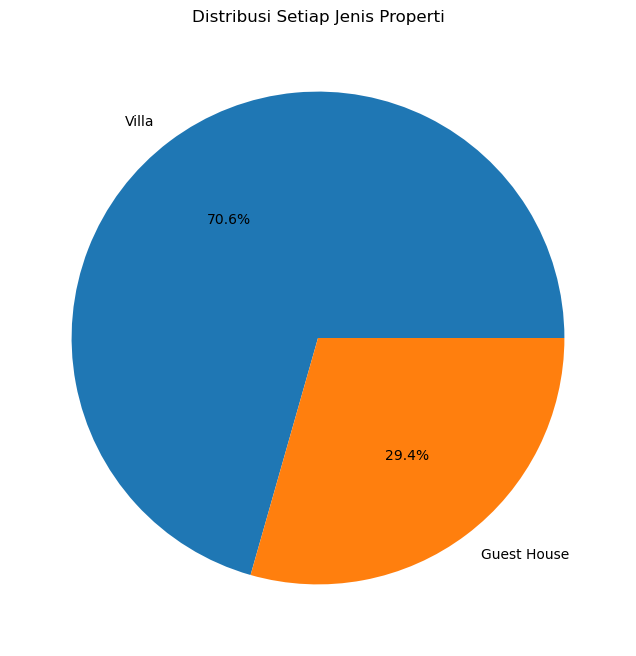

In [28]:
import matplotlib.pyplot as plt

# Hitung frekuensi setiap kategori
kategori = df['property_category'].value_counts()

# Plot pie chart
plt.figure(figsize=(8, 8))
kategori.plot(kind='pie', autopct='%1.1f%%', colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.title('Distribusi Setiap Jenis Properti')
plt.ylabel('')  # Menghilangkan label sumbu y
plt.show()


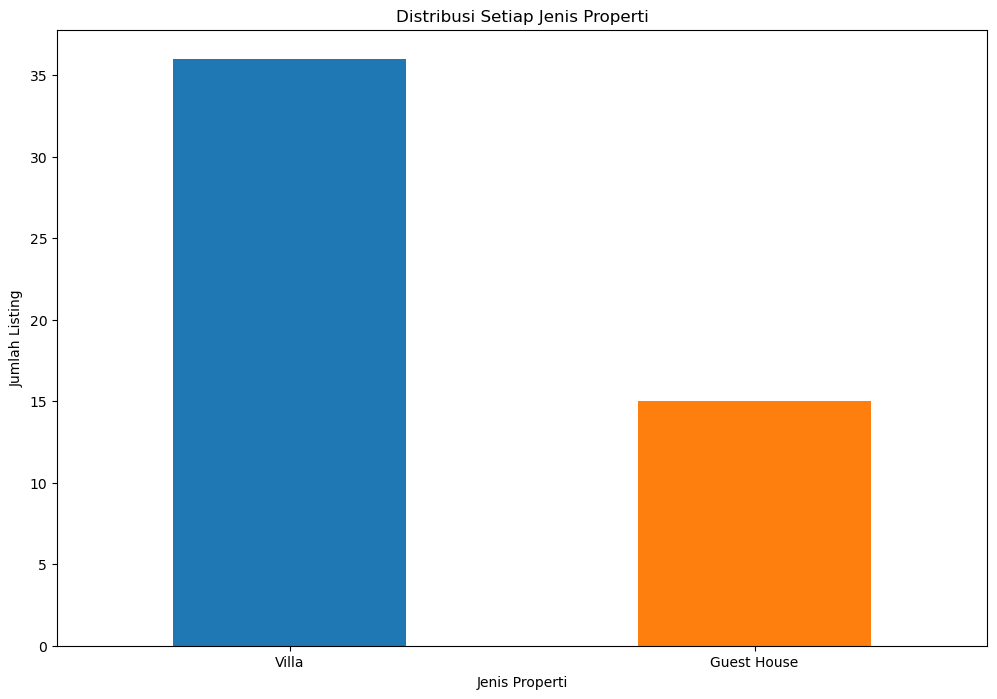

In [29]:
plt.figure(figsize=(12, 8))
df['property_category'].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Distribusi Setiap Jenis Properti')
plt.xlabel('Jenis Properti')
plt.ylabel('Jumlah Listing')
plt.xticks(rotation=0)
plt.show()

In [30]:
df

,name,location,bedrooms,bathrooms,property_type,price_range,url,agency,detailed_address,city,state,area,country,number_of_guests,rating,Amazing View,Amazing pool,Beachfront,Golfing,Guest House,Island life,Jungle View,Ocean view,Pool view,Residential,Rice paddy view,Style,Surfing,Tropical,View,property_category,currency,price_value,period,user_id
0,Uluwatu Modern Boho Villa Near Nyang Nyang Beach,"Jl. Batu Nunggul No.1, Pecatu, Kec. Kuta Sel.,...",2,2.0,"Amazing pool, Island life, Pool view, Surfing,...",$258 per 2 nights,https://www.bukitvista.com/property/uluwatu-mo...,Agus Weda,"Jl. Batu Nunggul No.1, Pecatu, Kec. Kuta Sel.,...",Bali,Bali,Uluwatu,Indonesia,4,4.40,0,1,0,0,0,1,0,0,1,0,0,0,1,1,1,Villa,USD,258,per 2 nights,1
1,Bingin Beach Hideaway: Group Villa with Pool &...,"Jl. Pantai Cemongkak Gg. Samuh Sari No.2, Peca...",3,3.0,"Amazing pool, Island life, Pool view, Surfing,...",Starting from USD 161 per night,https://www.bukitvista.com/property/bingin-bea...,Bukit Vista,"Jl. Pantai Cemongkak Gg. Samuh Sari No.2, Peca...",Bali,Bali,Bingin,Indonesia,6,NaN,0,1,0,0,0,1,0,0,1,0,0,0,1,1,1,Villa,USD,161,per night,2
2,4-Bedroom Mediterranean Luxury Villa with Ubud...,"Jl. Suweta, Ubud, Kecamatan Ubud, Kabupaten Gi...",4,4.0,"Amazing pool, Amazing View, Jungle View, Pool ...",USD 202 / Night,https://www.bukitvista.com/property/mediterran...,Bukit Vista,"Jl. Suweta, Ubud, Kecamatan Ubud, Kabupaten Gi...",Bali,Bali,Ubud,Indonesia,8,5.00,1,1,0,0,0,0,1,0,1,0,0,0,0,1,1,Villa,USD,202,per night,3
3,Luxurious 3-Bedroom Nusa Dua Seafront Villa w/...,"Jl. Raya Nusa Dua Selatan, Sawangan, Nusa Dua,...",3,4.0,"Beachfront, Villa",Starting from USD 715 per 2 nights,https://www.bukitvista.com/property/nusa-dua-s...,Konang,"Jl. Raya Nusa Dua Selatan, Sawangan, Nusa Dua,...",Bali,Bali,Nusa Dua,Indonesia,6,4.84,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,Villa,USD,715,per 2 nights,4
4,Grand Villa Retreat w/ Pool & Garden in Ungasan,"Jl. Pantai Balangan I No.9x, Ungasan, Kec. Kut...",2,2.0,"Amazing pool, Golfing, Pool view, Villa",Starting from USD 84 per night,https://www.bukitvista.com/property/grand-vill...,Bukit Vista,"Jl. Pantai Balangan I No.9x, Ungasan, Kec. Kut...",Bali,Bali,Balangan,Indonesia,4,4.70,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,Villa,USD,84,per night,5
5,Surfer’s Villa 4 Mins to Bingin & Dreamland Be...,"Pecatu, Kuta Selatan, Badung, Bali, Nusa Tengg...",2,2.5,"Pool view, Villa",Starting from USD 118 per night,https://www.bukitvista.com/property/surfers-vi...,Bukit Vista,"Jl. Bangbang Metuug, Pecatu, Kec. Kuta Sel., K...",Bali,Bali,Pecatu,Indonesia,4,4.57,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,Villa,USD,118,per night,6
6,Private Pool Villa Minutes from Bingin Surf Ha...,"Pecatu, Kuta Selatan, Badung, Bali, Nusa Tengg...",2,2.0,"Pool view, Villa",Starting from USD 165 per night,https://www.bukitvista.com/property/private-po...,Bukit Vista,"Jl. Bangbang Metuug, Pecatu, Kec. Kuta Sel., K...",Bali,Bali,Pecatu,Indonesia,4,4.57,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,Villa,USD,165,per night,7
7,Ungasan Exquisite Villa w/ Rooftop & Private P...,"Ungasan, Kuta Selatan, Badung, Bali, Nusa Teng...",3,3.5,"Amazing pool, Golfing, Surfing, Tropical, Villa",Starting from USD 167 per night,https://www.bukitvista.com/property/ungasan-ex...,Bukit Vista,"Jl. Pesakapan Indah No.9, Ungasan, Kec. Kuta S...",Bali,Bali,Ungasan,Indonesia,6,NaN,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,Villa,USD,167,per night,8
8,Sun-Soaked Canggu Villa Perfect for Families,"Tibubeneng, Kuta Utara, Badung, Bali, Nusa Ten...",2,2.0,Villa,Starting from USD 100 per night,https://www.bukitvista.com/property/sun-soaked...,Bukit Vista,"Tibubeneng, Kuta Utara, Badung, Bali",Bali,Bali,Canggu,Indonesia,4,4.25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Villa,USD,100,per night,9
9,Sunny Exquisite Umalas Villa: 20 Minutes to Ca...,Jl. Umalas Klecung No.34,2,2.0,"Guest House, Villa",Starting from USD 108 per night,https://www.bukitvista.com/property/sunny-exqu...,Bukit Vista,Jl. Umalas Klecung No.34,Bali,Bali,Umalas,Indonesia,4,4.57,0,0,0,0,1,0,0,0,0,

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               51 non-null     object 
 1   location           51 non-null     object 
 2   bedrooms           51 non-null     int64  
 3   bathrooms          51 non-null     float64
 4   property_type      51 non-null     object 
 5   price_range        51 non-null     object 
 6   url                51 non-null     object 
 7   agency             51 non-null     object 
 8   detailed_address   51 non-null     object 
 9   city               51 non-null     object 
 10  state              51 non-null     object 
 11  area               51 non-null     object 
 12  country            51 non-null     object 
 13  number_of_guests   51 non-null     int32  
 14  rating             49 non-null     float64
 15  Amazing View       51 non-null     int64  
 16  Amazing pool       51 non-nu

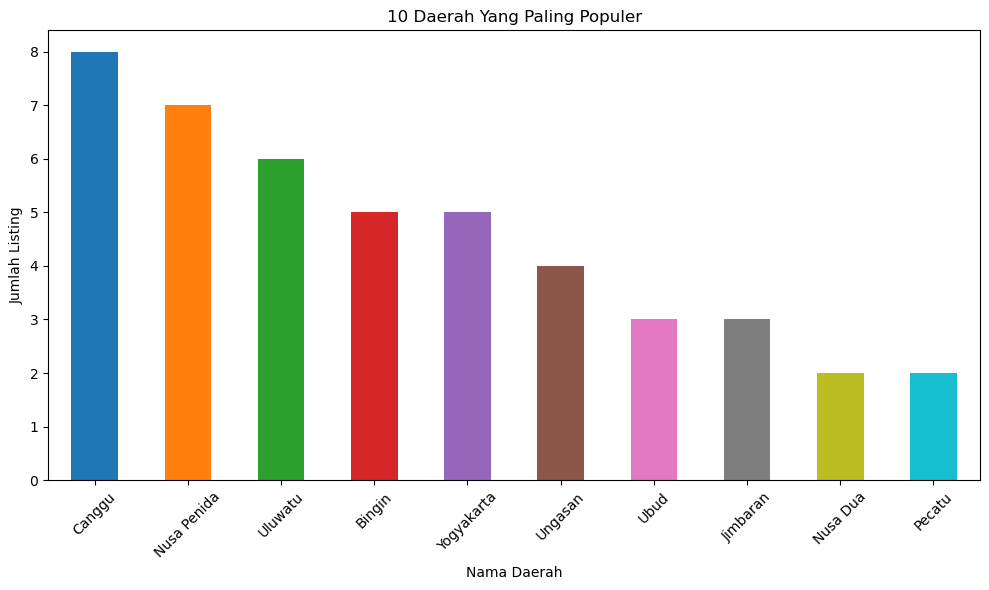

In [32]:
plt.figure(figsize=(10, 6))
df['area'].value_counts().head(10).plot(kind='bar', color=sns.color_palette())
plt.title('10 Daerah Yang Paling Populer')
plt.xlabel('Nama Daerah')
plt.ylabel('Jumlah Listing')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Feature Enggineering

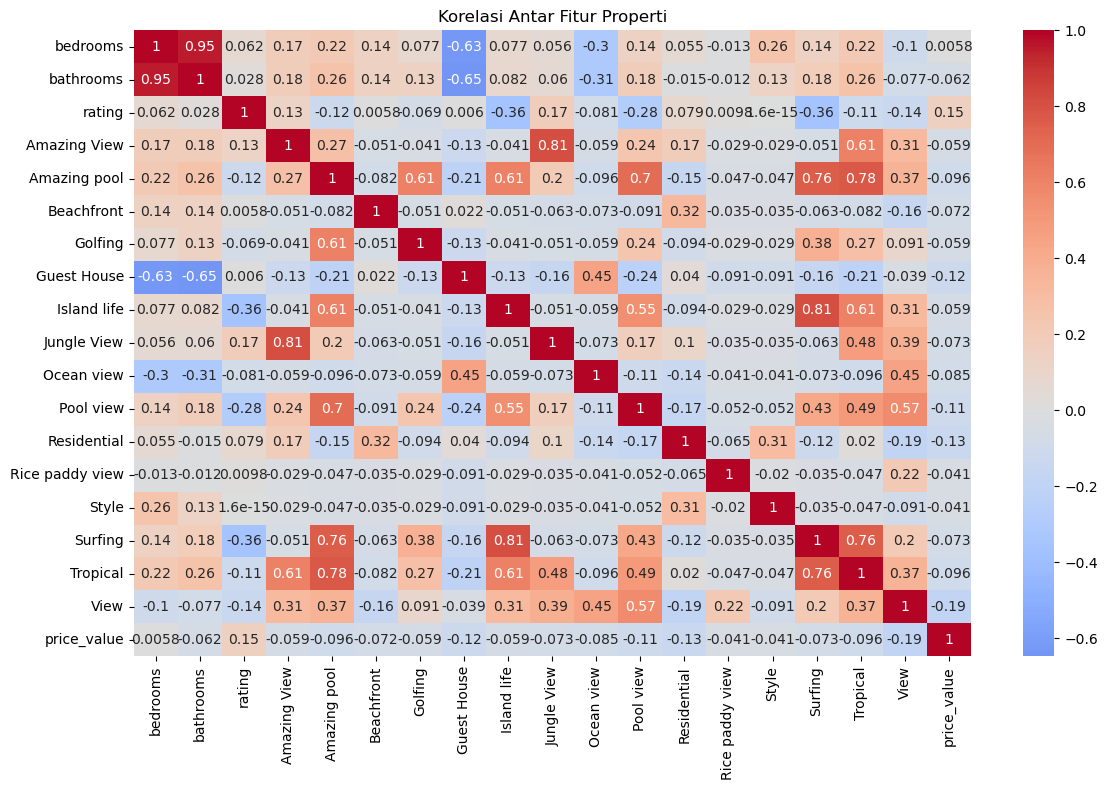

In [34]:
features = ['bedrooms','bathrooms','rating','Amazing View', 'Amazing pool', 'Beachfront', 'Golfing', 'Guest House',
            'Island life', 'Jungle View', 'Ocean view', 'Pool view', 'Residential',
            'Rice paddy view', 'Style', 'Surfing', 'Tropical', 'View','price_value']

# Hitung korelasi
corr = df[features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Korelasi Antar Fitur Properti')
plt.tight_layout()
plt.show()

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               51 non-null     object 
 1   location           51 non-null     object 
 2   bedrooms           51 non-null     int64  
 3   bathrooms          51 non-null     float64
 4   property_type      51 non-null     object 
 5   price_range        51 non-null     object 
 6   url                51 non-null     object 
 7   agency             51 non-null     object 
 8   detailed_address   51 non-null     object 
 9   city               51 non-null     object 
 10  state              51 non-null     object 
 11  area               51 non-null     object 
 12  country            51 non-null     object 
 13  number_of_guests   51 non-null     int32  
 14  rating             49 non-null     float64
 15  Amazing View       51 non-null     int64  
 16  Amazing pool       51 non-nu

In [36]:
# Hitung korelasi
corr = df[features].corr()

# Flatten korelasi dan urutkan berdasarkan nilai korelasi tertinggi
corr_unstacked = corr.unstack()
corr_unstacked = corr_unstacked[corr_unstacked != 1]  # Menghapus korelasi diri sendiri
corr_unstacked = corr_unstacked.abs().sort_values(ascending=False)

# Tampilkan korelasi tertinggi
print(corr_unstacked)


bedrooms      bathrooms       9.525721e-01
bathrooms     bedrooms        9.525721e-01
Amazing View  Jungle View     8.081220e-01
Jungle View   Amazing View    8.081220e-01
Island life   Surfing         8.081220e-01
                                  ...     
rating        Beachfront      5.793709e-03
price_value   bedrooms        5.776440e-03
bedrooms      price_value     5.776440e-03
Style         rating          1.585705e-15
rating        Style           1.585705e-15
Length: 342, dtype: float64


In [37]:
corr = df[features].corr()
corr

,bedrooms,bathrooms,rating,Amazing View,Amazing pool,Beachfront,Golfing,Guest House,Island life,Jungle View,Ocean view,Pool view,Residential,Rice paddy view,Style,Surfing,Tropical,View,price_value
bedrooms,1.000000,0.952572,6.172216e-02,0.173112,0.219858,0.135049,0.077148,-0.632460,0.077148,0.055882,-0.304314,0.139436,0.054611,-0.013172,2.555287e-01,0.135049,0.219858,-0.101001,0.005776
bathrooms,0.952572,1.000000,2.821122e-02,0.180947,0.262898,0.142050,0.131332,-0.647757,0.081718,0.060191,-0.311856,0.177587,-0.014860,-0.012258,1.266626e-01,0.182980,0.262898,-0.077084,-0.061965
rating,0.061722,0.028211,1.000000e+00,0.126359,-0.121668,0.005794,-0.068766,0.006028,-0.363477,0.173811,-0.081167,-0.279908,0.078916,0.009824,1.585705e-15,-0.363477,-0.110080,-0.138360,0.153221
Amazing View,0.173112,0.180947,1.263586e-01,1.000000,0.273091,-0.050508,-0.040816,-0.130410,-0.040816,0.808122,-0.058938,0.239756,0.171457,-0.028571,-2.857143e-02,-0.050508,0.612789,0.312984,-0.058864
Amazing pool,0.219858,0.262898,-1.216679e-01,0.273091,1.000000,-0.082423,0.612789,-0.212814,0.612789,0.197814,-0.096181,0.698238,-0.152617,-0.046625,-4.662524e-02,0.758288,0.778261,0.366040,-0.096043
Beachfront,0.135049,0.142050,5.793709e-03,-0.050508,-0.082423,1.000000,-0.050508,0.021517,-0.050508,-0.062500,-0.072932,-0.091287,0.321465,-0.035355,-3.535534e-02,-0.062500,-0.082423,-0.161374,-0.072172
Golfing,0.077148,0.131332,-6.876599e-02,-0.040816,0.612789,-0.050508,1.000000,-0.130410,-0.040816,-0.050508,-0.058938,0.239756,-0.093522,-0.028571,-2.857143e-02,0.378807,0.273091,0.091287,-0.058867
Guest House,-0.632460,-0.647757,6.027555e-03,-0.130410,-0.212814,0.021517,-0.130410,1.000000,-0.130410,-0.161374,0.451946,-0.235702,0.039841,-0.091287,-9.128709e-02,-0.161374,-0.212814,-0.038889,-0.116978
Island life,0.077148,0.081718,-3.634774e-01,-0.040816,0.612789,-0.050508,-0.040816,-0.130410,1.000000,-0.050508,-0.058938,0.553283,-0.093522,-0.028571,-2.857143e-02,0.808122,0.612789,0.312984,-0.058844
Jungle View,0.055882,0.060191,1.738113e-01,0.808122,0.197814,-0.062500,-0.050508,-0.161374,-0.050508,1.000000,-0.072932,0.167360,0.102869,-0.035355,-3.535534e-02,-0.062500,0.478051,0.387298,-0.072756


Dari tabel korelasi yang Anda berikan, berikut adalah beberapa poin penting yang dapat diambil:

1. **Korelasi Tinggi:**
   - **`bedrooms` dan `bathrooms`** memiliki korelasi yang sangat tinggi, yaitu 0.952572. Ini menunjukkan bahwa semakin banyak kamar tidur di suatu properti, semakin banyak kamar mandinya. Ini adalah hubungan yang cukup logis karena properti yang lebih besar (dengan lebih banyak kamar tidur) biasanya memerlukan lebih banyak kamar mandi.
   
   - **`Amazing pool` dan `Surfing`** memiliki korelasi positif yang kuat, yaitu 0.758288. Artinya, properti dengan kolam renang yang luar biasa cenderung terkait dengan properti yang juga memiliki aktivitas berselancar, mungkin karena keduanya ditemukan di lokasi yang berfokus pada aktivitas rekreasi.

   - **`Island life` dan `Jungle View`** memiliki korelasi tinggi 0.808122. Ini menunjukkan bahwa properti yang menawarkan kehidupan pulau cenderung memiliki pemandangan hutan tropis, yang sering ditemukan di lokasi-lokasi pulau tropis atau terpencil.

2. **Korelasi Moderat:**
   - **`Amazing View` dan `Jungle View`** memiliki korelasi 0.808122, menunjukkan bahwa properti dengan pemandangan yang luar biasa sering memiliki pemandangan hutan tropis.

   - **`Tropical` dan `Surfing`** juga memiliki korelasi moderat 0.758288, yang mengindikasikan bahwa banyak properti tropis juga menyediakan fasilitas untuk berselancar, yang sering kali ditemukan di lokasi pantai tropis.

   - **`price_value`** cenderung memiliki korelasi yang lebih lemah dengan sebagian besar fitur lainnya, dengan korelasi terendah terhadap **`bathrooms`** (-0.061965) dan **`bedrooms`** (0.005776). Ini bisa menunjukkan bahwa nilai harga properti tidak terlalu dipengaruhi oleh jumlah kamar tidur atau kamar mandi, meskipun faktor lain seperti lokasi, pemandangan, atau fasilitas (seperti kolam renang dan pantai) bisa berperan lebih besar.

3. **Korelasi Negatif:**
   - **`Guest House`** memiliki korelasi negatif yang cukup kuat dengan **`bedrooms`** dan **`bathrooms`** (-0.632460 dan -0.647757). Ini bisa menunjukkan bahwa properti yang berfungsi sebagai rumah tamu lebih kecil dan mungkin memiliki lebih sedikit kamar tidur dan kamar mandi dibandingkan dengan properti utama.
   
   - **`Ocean view`** dan **`bedrooms`** (-0.304314) menunjukkan korelasi negatif sedang, yang bisa berarti bahwa properti dengan pemandangan laut mungkin tidak selalu memiliki banyak kamar tidur.

4. **Korelasi Lemah:**
   - **`rating`** menunjukkan korelasi yang sangat lemah dengan sebagian besar fitur lainnya, hanya memiliki korelasi positif kecil dengan **`bedrooms`** (0.061722) dan **`bathrooms`** (0.028211), yang menunjukkan bahwa rating properti lebih dipengaruhi oleh faktor-faktor lain yang tidak terkait langsung dengan ukuran fisik properti.

Secara keseluruhan, korelasi yang tinggi antara jumlah kamar tidur dan kamar mandi mencerminkan hubungan logis antara ukuran properti dan jumlah fasilitasnya. Selain itu, korelasi kuat antara fasilitas seperti **kolam renang** dan **surfing** menunjukkan bahwa properti dengan fasilitas rekreasi cenderung saling terkait.

## Marchine Learning

In [40]:
#df['rating'].fillna(df['rating'].mean(), inplace=True)
#df['rating'] = df['rating'].astype(float).round(1)
df['rating'] = df['rating'].fillna(df['rating'].mean())


In [41]:
!pip install numpy==1.24.4

  Using cached numpy-1.24.4.tar.gz (10.9 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [33 lines of output]
  Traceback (most recent call last):
    File "C:\Users\User\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
      main()
    File "C:\Users\User\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 335, in main
      json_out['return_val'] = hook(**hook_input['kwargs'])
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\User\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 112, in get_requires_for_build_wheel
      backend = _build_backend()
                ^^^^^^^^^^^^^^^^
    File "C:\Users\User\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 77, in _build_backend
      obj = import_module(mod_path)
            ^^^^^^^^^^^^^^^^^^^^^^^
 

### Model Random forest

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# === Step 1: Define features and target ===
features = [
    'property_category', 'bedrooms', 'bathrooms', 'city', 'state', 'area',
    'number_of_guests', 'price_value', 'currency', 'period', 'Amazing View',
    'Amazing pool', 'Beachfront', 'Golfing', 'Guest House', 'Island life',
    'Jungle View', 'Ocean view', 'Pool view', 'Residential', 'Rice paddy view', 'Surfing'
]
target = 'rating'

# Ambil data untuk fitur dan target
x = df[features]
y = df[target]

# Encode fitur kategorikal
cat_cols = x.select_dtypes(include='object').columns
x = pd.get_dummies(x, columns=cat_cols)

# === Step 2: Split data into training and testing ===
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# === Step 3: Train Random Forest model ===
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

# === Step 4: Evaluate Model ===
y_pred = rf.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"MAPE: {mape:.2f}%")


RMSE: 0.1186
MAE : 0.0884
MAPE: 1.84%


Penjelasan:

Step 1: Mendefinisikan fitur dan target.

Step 2: Memisahkan data menjadi train dan test set.

Step 3: Melatih model RandomForestRegressor dengan 100 estimator.

Step 4: Menghitung RMSE, MAE, dan MAPE untuk evaluasi model.

In [45]:
def recommend_stays_for_user(user_id, df, model, x_train, top_n=5, max_price=None, preferred_location=None):
    import pandas as pd

    # Ambil semua property (stays)
    all_stays = df['name'].unique()

    # Ambil property yang sudah dirating oleh user
    rated_stays = df[df['user_id'] == user_id]['name'].unique()
    
    # Ambil property yang belum dirating oleh user
    unseen_stays = [stay for stay in all_stays if stay not in rated_stays]

    if not unseen_stays:
        print(f"User ID {user_id} sudah melihat semua stays!")
        return []

    # Buat dataframe untuk prediksi
    user_data = pd.DataFrame({
        'user_id': [user_id]*len(unseen_stays),
        'name': unseen_stays
    })

    # Merge fitur lain seperti lokasi dan harga (jika ada)
    if 'location' in df.columns:
        locations = df.drop_duplicates('name')[['name', 'location']]
        user_data = user_data.merge(locations, on='name', how='left')

    if 'price' in df.columns:
        prices = df.drop_duplicates('name')[['name', 'price']]
        user_data = user_data.merge(prices, on='name', how='left')

    # Filtering jika ada batas harga atau lokasi yang diinginkan
    if max_price is not None:
        user_data = user_data[user_data['price'] <= max_price]
        
    if preferred_location is not None:
        user_data = user_data[user_data['location'] == preferred_location]

    # Kalau setelah filtering tidak ada data
    if user_data.empty:
        print("No stays match the filtering criteria. Showing all unseen stays instead.")
        user_data = pd.DataFrame({
            'user_id': [user_id]*len(unseen_stays),
            'name': unseen_stays
        })
        if 'location' in df.columns:
            user_data = user_data.merge(locations, on='name', how='left')
        if 'price' in df.columns:
            user_data = user_data.merge(prices, on='name', how='left')

    # Encode fitur sama seperti saat training model
    user_data_encoded = pd.get_dummies(user_data)

    # Menyamakan kolom dengan yang ada di x_train
    missing_cols = set(x_train.columns) - set(user_data_encoded.columns)
    for col in missing_cols:
        user_data_encoded[col] = 0
    user_data_encoded = user_data_encoded[x_train.columns]

    # Prediksi rating untuk property yang belum dilihat
    preds = model.predict(user_data_encoded)

    # Gabungkan hasil prediksi dengan nama property
    recommendation = pd.DataFrame({
        'stay': user_data['name'].values,
        'predicted_rating': preds
    })

    # Ambil top_n rekomendasi berdasarkan prediksi rating
    top_recommendations = recommendation.sort_values('predicted_rating', ascending=False).head(top_n)

    # Print hasil rekomendasi
    print(f"\nTop {top_n} recommended stays for User ID {user_id}:")
    for idx, row in top_recommendations.iterrows():
        print(f"🏨 {row['stay']} — Predicted Rating: {row['predicted_rating']:.2f}")

    return top_recommendations


In [87]:
pip install gradio


     ---------------------------------------- 0.0/42.9 kB ? eta -:--:--
     ---------------------------- ----------- 30.7/42.9 kB 1.3 MB/s eta 0:00:01
     -------------------------------------- 42.9/42.9 kB 695.2 kB/s eta 0:00:00
   ---------------------------------------- 0.0/54.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/54.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/54.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/54.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/54.0 MB 640.0 kB/s eta 0:01:25
   ---------------------------------------- 0.0/54.0 MB 393.8 kB/s eta 0:02:18
   ---------------------------------------- 0.0/54.0 MB 393.8 kB/s eta 0:02:18
   ---------------------------------------- 0.0/54.0 MB 393.8 kB/s eta 0:02:18
   ---------------------------------------- 0.0/54.0 MB 393.8 kB/s eta 0:02:18
   ---------------------------------------- 0.1/54.0 MB 344.8 kB/s eta 0:02:37
   -----------

ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\User\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "C:\Users\User\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 98, in read
    data: bytes = self.__fp.read(amt)
                  ^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\http\client.py", line 479, in read
    s = self.fp.read(amt)
        ^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\socket.py", line 708, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^

In [88]:
import gradio as gr

def gradio_recommend(user_id, max_price, preferred_location):
    # Gunakan fungsi rekomendasi yang sudah kita buat
    results = recommend_stays_for_user(
        user_id=int(user_id),
        df_rent=df_rent,
        model=rf,  # Model Random Forest yang sudah dilatih
        x_train=x_train,
        top_n=5,
        max_price=max_price if max_price else None,
        preferred_location=preferred_location if preferred_location != "Any" else None
    )

    if results is None or results.empty:
        return "No recommendations available."

    # Format output rekomendasi
    output = ""
    for idx, row in results.iterrows():
        output += f"🏨 {row['stay']} — Predicted Rating: {row['predicted_rating']:.2f}\n"
    return output

# Daftar lokasi unik
location_list = ['Any'] + sorted(df_rent['location'].dropna().unique())

# Buat interface Gradio
with gr.Blocks() as demo:
    gr.Markdown("## 🏡 Stay Recommendation System")

    user_id_input = gr.Number(label="User ID", precision=0)
    max_price_input = gr.Number(label="Maximum Price (optional)", precision=0)
    location_input = gr.Dropdown(choices=location_list, label="Preferred Location", value="Any")

    submit_button = gr.Button("Get Recommendations")

    output_text = gr.Textbox(label="Top Recommendations", lines=10)

    submit_button.click(
        gradio_recommend,
        inputs=[user_id_input, max_price_input, location_input],
        outputs=output_text
    )

demo.launch()


ModuleNotFoundError: No module named 'gradio'